# 🔴 Notebook 3 — Production Monitoring & Drift Detection
## Watching the Model Degrade in Real Time

This notebook simulates exactly what happens after deployment:

1. **Score 6 production cohorts** drawn from a drifting population
2. **Detect score drift** via Population Stability Index (PSI)
3. **Detect feature drift** via KS tests + feature-level PSI
4. **Track AUROC degradation** cohort by cohort
5. **Fire retrain alerts** when thresholds are crossed
6. **Visualise the drift story** end-to-end

**The scenario:** months 1–3 are stable. Starting month 4 (cohort 3):
- Monthly charges rise (price increase)
- MOU falls (usage erosion / competition)
- Equipment ages (no device upgrade programme)
- Customer care calls spike (service degradation)

The model was trained on the reference population. It doesn't know  
the world has changed.

---


## 0. Setup

In [15]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f9f9f9",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
    "font.size": 11, "axes.titlesize": 13, "legend.frameon": False,
})
C_BLUE, C_RED, C_GREEN, C_ORANGE, C_GRAY = (
    "#2E86AB", "#E05C5C", "#4CAF82", "#F5A623", "#8E9AAF"
)
print("Setup ✓")

Setup ✓


In [16]:
import mlflow
from src.data.loader import (
    download_data, preprocess, generate_weibull_event_log,
    get_feature_cols, make_temporal_cohorts
)
from src.models.churn_model import train, score_cohorts

mlflow.set_tracking_uri("file:///" + str(Path("..").resolve() / "mlruns"))

N_COHORTS   = 6
DRIFT_START = 3
HORIZON     = 90
TARGET      = f"churn_{HORIZON}d"

print("Loading data and training model…")
raw      = download_data()
df       = preprocess(raw)
df       = generate_weibull_event_log(df, seed=42)
features = get_feature_cols(df)
cohorts  = make_temporal_cohorts(df, n_cohorts=N_COHORTS, drift_start=DRIFT_START)

base  = cohorts[0]
split = int(0.8 * len(base))
train_df = base.iloc[:split].copy()
test_df  = base.iloc[split:].copy()

model, calibrated, _, _, _, train_metrics = train(
    train_df, features, horizon=HORIZON,
    experiment_name="notebook-monitoring", run_name="monitor_90d",
)
print(f"Model trained — CV AUROC: {train_metrics['cv_auroc_mean']:.4f}")

Loading data and training model…
  Loading Cell2Cell from /Users/youssefmousaaid/Desktop/Projects/churn-monitoring/data/cell2celltrain.csv …
  [90d] CV AUROC: 0.5330 ± 0.0772
Model trained — CV AUROC: 0.5330


---
## 1. Score All Production Cohorts

Each cohort represents one month of production scoring.  
Cohorts 0–2 are drawn from the reference distribution.  
Cohorts 3–5 have progressively injected drift.


In [17]:
print("Scoring all cohorts…\n")
scored = score_cohorts(calibrated, cohorts, features, horizon=HORIZON)
print(f"\nScored {len(scored)} cohorts")

Scoring all cohorts…

  Cohort 0: n=1,200 | churn_rate=0.033 | AUROC=0.6733
  Cohort 1: n=1,200 | churn_rate=0.021 | AUROC=0.5751
  Cohort 2: n=1,200 | churn_rate=0.024 | AUROC=0.5420
  Cohort 3: n=1,200 | churn_rate=0.025 | AUROC=0.5306
  Cohort 4: n=1,200 | churn_rate=0.031 | AUROC=0.5267
  Cohort 5: n=1,200 | churn_rate=0.031 | AUROC=0.5288

Scored 6 cohorts


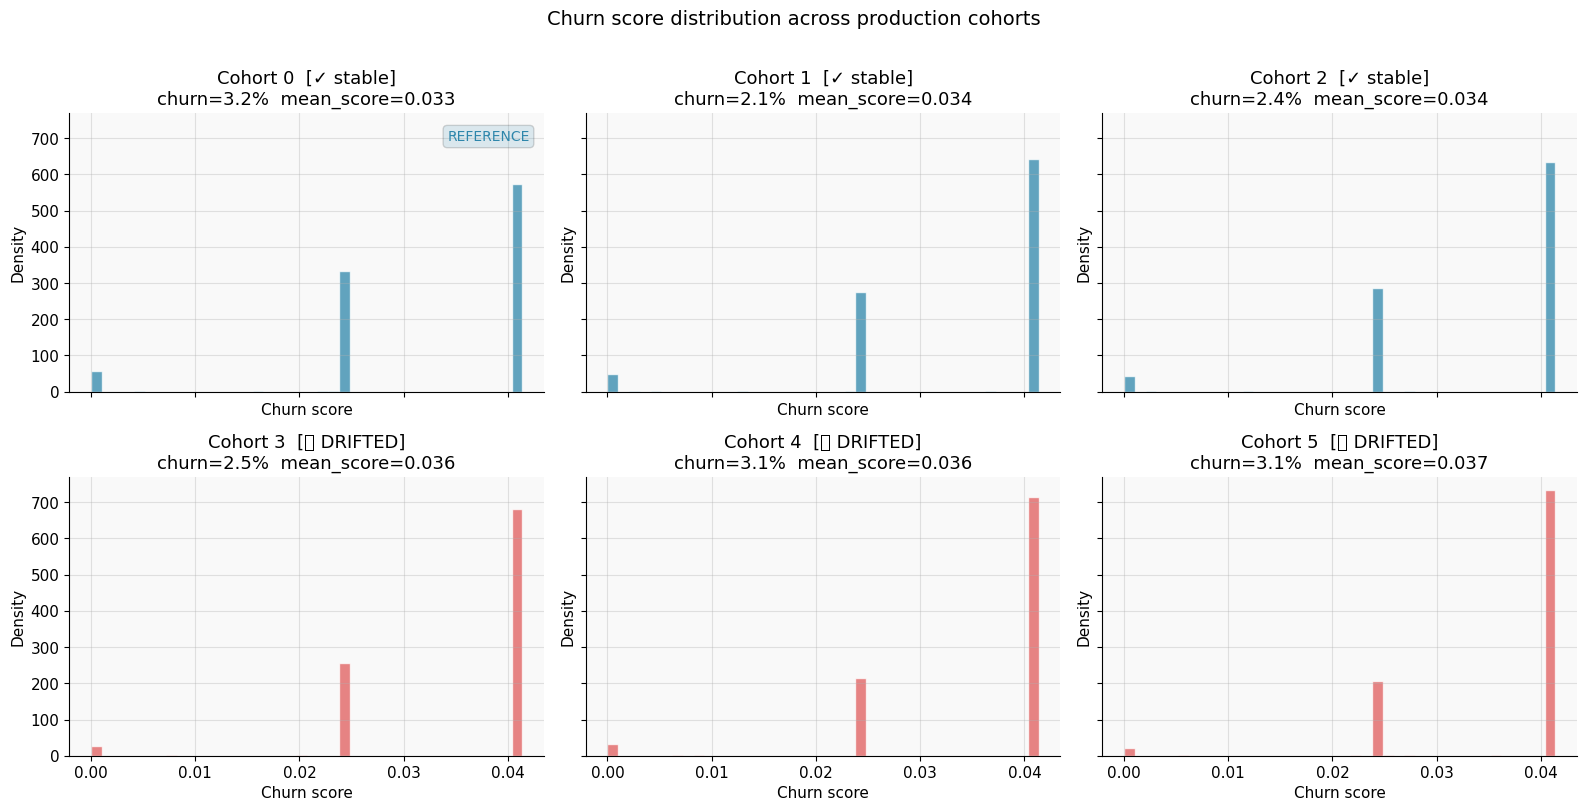

In [18]:
# Score distributions side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (cohort, ax) in enumerate(zip(scored, axes)):
    churn_rate = cohort[TARGET].mean()
    color = C_RED if i >= DRIFT_START else C_BLUE
    title_suffix = "🔴 DRIFTED" if i >= DRIFT_START else "✓ stable"

    ax.hist(cohort["churn_score"].clip(0, 1), bins=40, color=color,
            alpha=0.75, edgecolor="white", density=True)
    ax.set_title(f"Cohort {i}  [{title_suffix}]\n"
                 f"churn={churn_rate:.1%}  mean_score={cohort['churn_score'].mean():.3f}")
    ax.set_xlabel("Churn score")
    ax.set_ylabel("Density")

    if i == 0:
        ax.text(0.97, 0.90, "REFERENCE", transform=ax.transAxes,
                ha="right", fontsize=10, color=C_BLUE,
                bbox=dict(boxstyle="round", facecolor=C_BLUE, alpha=0.15))

plt.suptitle("Churn score distribution across production cohorts",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Population Stability Index (PSI)

PSI measures how much a distribution has shifted vs the reference:

$$\text{PSI} = \sum_{i=1}^{n} \left( A_i\% - E_i\% \right) \cdot \ln\!\left(\frac{A_i\%}{E_i\%}\right)$$

**Rules of thumb:**
| PSI | Status | Action |
|---|---|---|
| < 0.10 | ✅ Stable | No action |
| 0.10–0.20 | ⚠️ Warning | Monitor closely |
| > 0.20 | 🔴 Retrain | Investigate + retrain |


In [19]:
from src.monitoring.drift import psi, psi_label

ref_scores = scored[0]["churn_score"].values
psi_values = []
statuses   = []

print(f"{'Cohort':>8} {'PSI':>10} {'Status':>12} {'Mean score':>12}")
print("-" * 50)
for i, cohort in enumerate(scored):
    cur = cohort["churn_score"].values
    p   = psi(ref_scores, cur)
    s   = psi_label(p)
    psi_values.append(p)
    statuses.append(s)
    icon = {"stable": "✓", "warning": "⚠", "retrain": "✗"}[s]
    print(f"  {i:>6}   {p:>9.4f}   {icon} {s:>8}   {cur.mean():>11.4f}")

  Cohort        PSI       Status   Mean score
--------------------------------------------------
       0      0.0000   ✓   stable        0.0330
       1      0.0216   ✓   stable        0.0344
       2      0.0172   ✓   stable        0.0344
       3      0.0631   ✓   stable        0.0356
       4      0.0994   ✓   stable        0.0361
       5      0.1357   ⚠  warning        0.0367


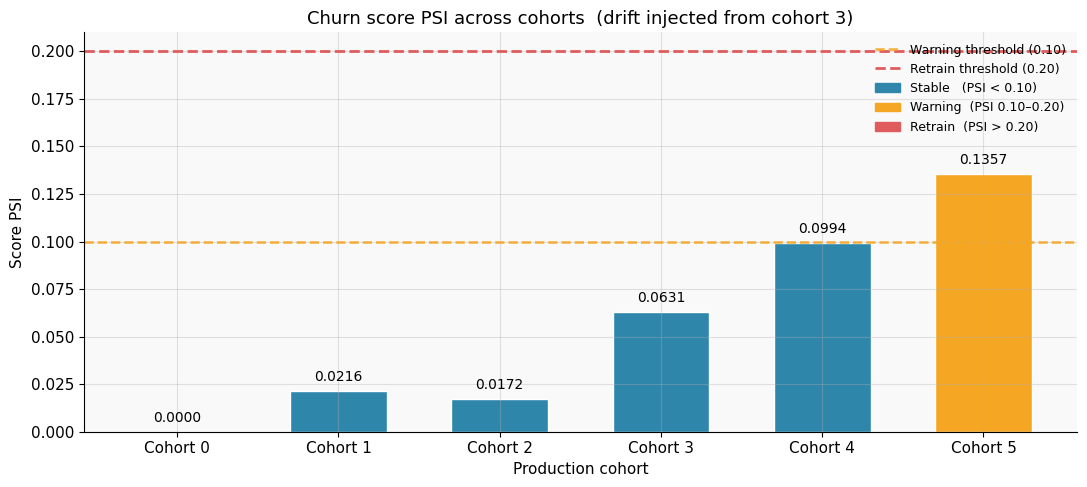

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))

color_map = {"stable": C_BLUE, "warning": C_ORANGE, "retrain": C_RED}
colors    = [color_map[s] for s in statuses]
bars      = ax.bar(range(N_COHORTS), psi_values, color=colors,
                   width=0.6, edgecolor="white")

ax.axhline(0.10, ls="--", color=C_ORANGE, lw=1.8, alpha=0.9,
           label="Warning threshold (0.10)")
ax.axhline(0.20, ls="--", color=C_RED,    lw=2.0,
           label="Retrain threshold (0.20)")

for bar, val, s in zip(bars, psi_values, statuses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=10,
            fontweight="bold" if s == "retrain" else "normal")

legend_patches = [
    mpatches.Patch(color=C_BLUE,   label="Stable   (PSI < 0.10)"),
    mpatches.Patch(color=C_ORANGE, label="Warning  (PSI 0.10–0.20)"),
    mpatches.Patch(color=C_RED,    label="Retrain  (PSI > 0.20)"),
]
existing = ax.get_legend_handles_labels()
ax.legend(handles=existing[0] + legend_patches,
          labels=existing[1] + [p.get_label() for p in legend_patches],
          fontsize=9)

ax.set_xlabel("Production cohort")
ax.set_ylabel("Score PSI")
ax.set_title(f"Churn score PSI across cohorts  (drift injected from cohort {DRIFT_START})")
ax.set_xticks(range(N_COHORTS))
ax.set_xticklabels([f"Cohort {i}" for i in range(N_COHORTS)])
plt.tight_layout()
plt.show()

---
## 3. Feature-Level Drift (KS Test + Feature PSI)

Score drift tells us *something* changed.  
Feature drift tells us *what* changed and *which* features to investigate.

We run:
- **KS test** (continuous features): tests whether two samples come from the same distribution
- **Chi-squared test** (categorical features): tests independence from reference counts
- **Feature PSI**: quantifies the magnitude of shift per feature

A feature is flagged as drifted if `p < 0.05` AND `feature PSI > 0.10`.


In [21]:
from src.monitoring.drift import detect_feature_drift, KEY_DRIFT_FEATURES

ref_cohort  = scored[0]
key_feats   = [f for f in KEY_DRIFT_FEATURES if f in ref_cohort.columns]

print("Feature drift — Cohort 5 vs Reference:\n")
print(f"{'Feature':<30} {'Test':>6} {'PSI':>8} {'p-value':>10} {'Drifted':>10}")
print("-" * 68)

results_c5 = detect_feature_drift(ref_cohort, scored[5], key_feats)
for r in results_c5:
    icon = "✗ YES" if r.drifted else "✓ no"
    print(f"  {r.feature:<28} {r.test:>5}  {r.psi:>7.4f}  "
          f"{r.p_value:>9.4f}  {icon}")

Feature drift — Cohort 5 vs Reference:

Feature                          Test      PSI    p-value    Drifted
--------------------------------------------------------------------
  custcare                        ks   9.3897     0.0000  ✗ YES
  custcare_rate                   ks   8.5851     0.0000  ✗ YES
  eqp_age_ratio                   ks   2.1488     0.0000  ✗ YES
  revenue_per_mou                 ks   0.5970     0.0000  ✗ YES
  revenue                         ks   0.3362     0.0000  ✗ YES
  eqpdays                         ks   0.2365     0.0000  ✗ YES
  mou                             ks   0.1413     0.0000  ✗ YES
  overage                         ks   0.0367     0.0125  ✓ no
  overage_rate                    ks   0.0293     0.1607  ✓ no
  drop_rate                       ks   0.0118     0.2486  ✓ no


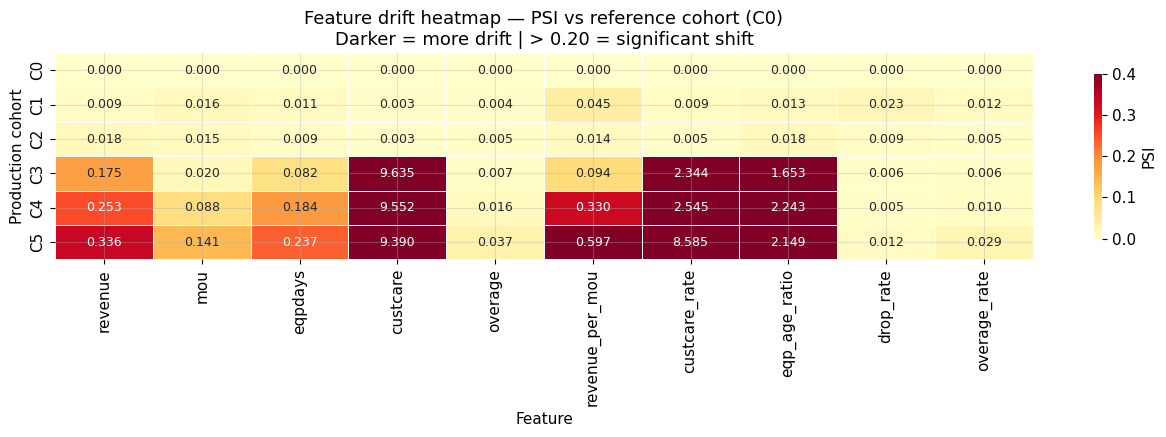

In [22]:
# Build PSI matrix across all cohorts × key features
psi_matrix, cohort_labels = [], []
for cohort in scored:
    row = [psi(ref_cohort[f].fillna(0).values,
               cohort[f].fillna(0).values)
           for f in key_feats]
    psi_matrix.append(row)
    cohort_labels.append(f"C{int(cohort['cohort'].iloc[0])}")

psi_df = pd.DataFrame(psi_matrix, index=cohort_labels, columns=key_feats)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(psi_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=0.40,
            cbar_kws={"label": "PSI", "shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Feature drift heatmap — PSI vs reference cohort (C0)\n"
             "Darker = more drift | > 0.20 = significant shift")
ax.set_xlabel("Feature")
ax.set_ylabel("Production cohort")
plt.tight_layout()
plt.show()

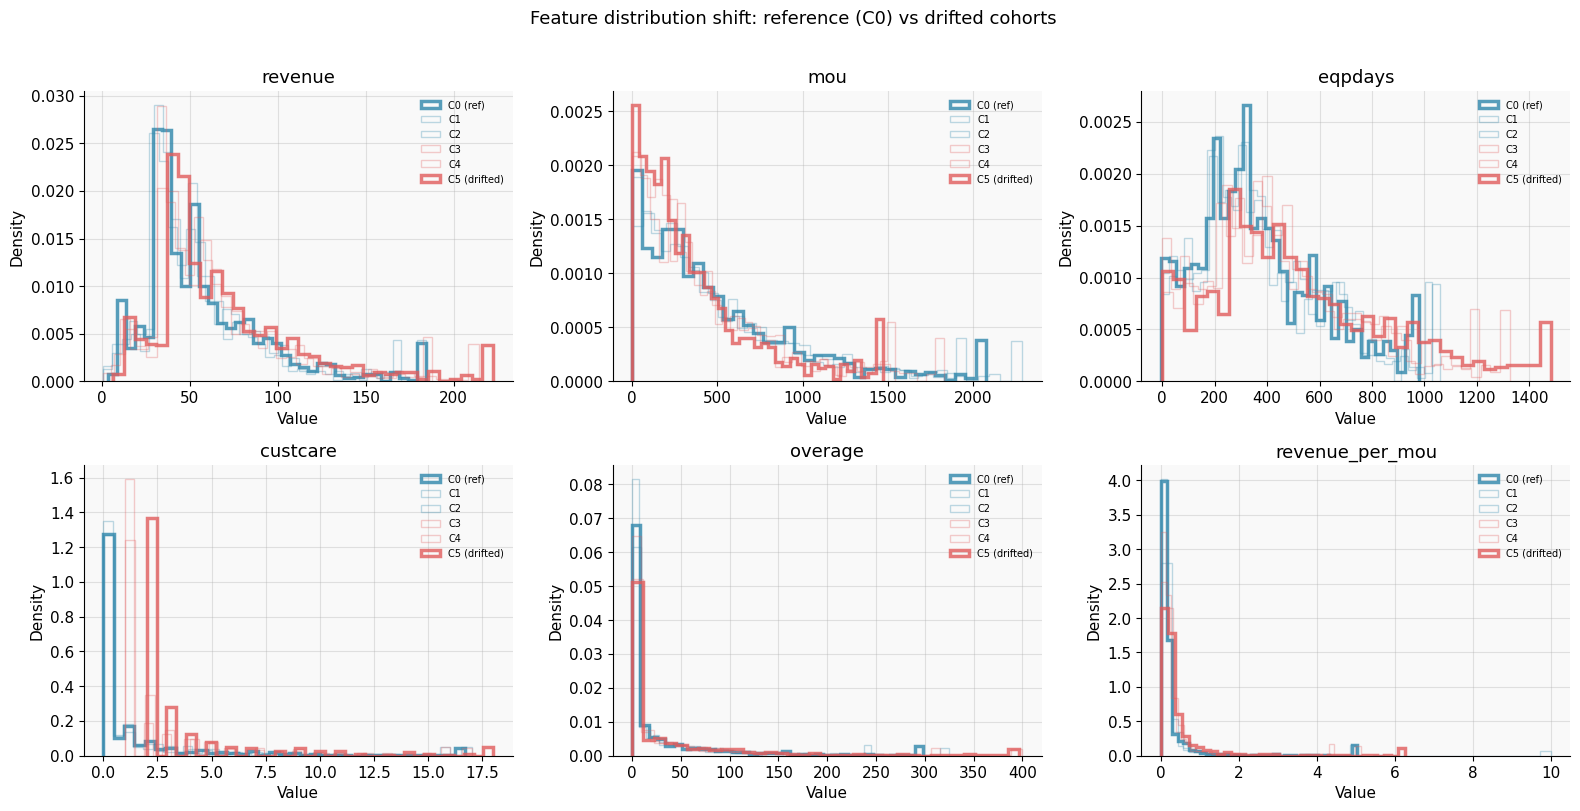

In [23]:
# Show which specific features changed
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

DRIFT_FEATS_SHOW = [f for f in ["revenue", "mou", "eqpdays",
                                 "custcare", "overage", "revenue_per_mou"]
                    if f in ref_cohort.columns]

for ax, feat in zip(axes, DRIFT_FEATS_SHOW):
    for i, cohort in enumerate(scored):
        color = C_RED if i >= DRIFT_START else C_BLUE
        alpha = 0.8 if i in (0, len(scored)-1) else 0.3
        lw    = 2.5 if i in (0, len(scored)-1) else 1.0
        label = f"C{i} (ref)" if i == 0 else (f"C{i} (drifted)" if i == len(scored)-1 else f"C{i}")
        data  = cohort[feat].clip(upper=cohort[feat].quantile(0.98))
        ax.hist(data, bins=35, density=True, histtype="step",
                color=color, lw=lw, alpha=alpha, label=label)
    ax.set_title(f"{feat}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("Feature distribution shift: reference (C0) vs drifted cohorts",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. AUROC Degradation Under Drift

As the population drifts away from what the model was trained on,  
its discriminative power erodes. The AUROC tracks this in real time.

**Why does AUROC drop?** The model learned decision boundaries on the  
reference distribution. When `revenue` and `eqpdays` shift, the  
boundary is no longer optimal for the new population.


In [24]:
from sklearn.metrics import roc_auc_score, average_precision_score

auroc_vals, auprc_vals = [], []
AUROC_THRESHOLD = 0.70

for i, cohort in enumerate(scored):
    y_true = cohort[TARGET]
    y_pred = cohort["churn_score"]
    try:
        auroc_vals.append(roc_auc_score(y_true, y_pred))
        auprc_vals.append(average_precision_score(y_true, y_pred))
    except Exception:
        auroc_vals.append(None)
        auprc_vals.append(None)

print(f"{'Cohort':>8} {'AUROC':>8} {'AUPRC':>8} {'vs ref':>8} {'Alert':>10}")
print("-" * 50)
ref_auroc = auroc_vals[0]
for i, (a, p) in enumerate(zip(auroc_vals, auprc_vals)):
    if a is None:
        continue
    delta = a - ref_auroc
    alert = "⚠ RETRAIN" if a < AUROC_THRESHOLD else "✓ OK"
    print(f"  {i:>6}   {a:.4f}  {p:.4f}  {delta:>+7.4f}   {alert}")

  Cohort    AUROC    AUPRC   vs ref      Alert
--------------------------------------------------
       0   0.6733  0.0494  +0.0000   ⚠ RETRAIN
       1   0.5751  0.0245  -0.0982   ⚠ RETRAIN
       2   0.5420  0.0263  -0.1313   ⚠ RETRAIN
       3   0.5306  0.0267  -0.1427   ⚠ RETRAIN
       4   0.5267  0.0325  -0.1466   ⚠ RETRAIN
       5   0.5288  0.0327  -0.1445   ⚠ RETRAIN


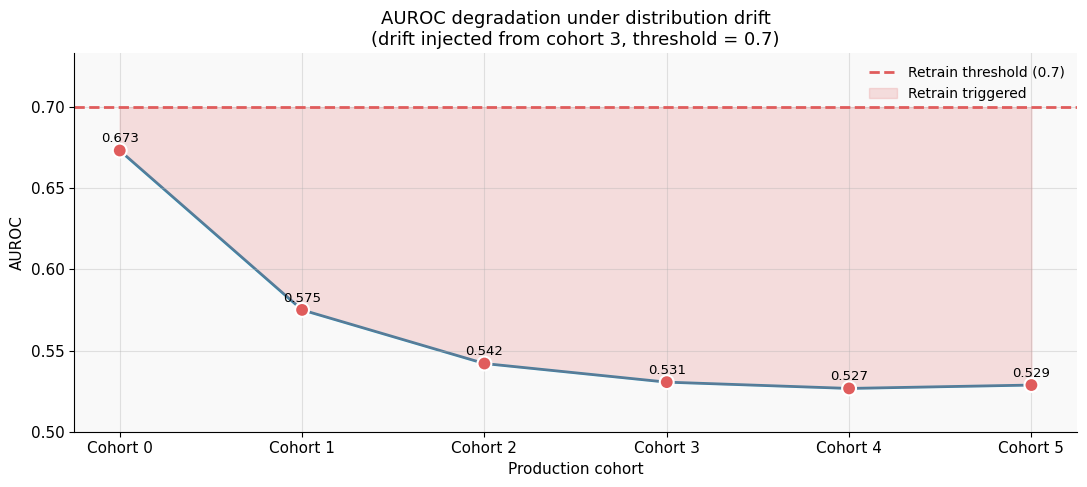

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))

cohort_ids = list(range(N_COHORTS))
dot_colors = [C_RED if (a and a < AUROC_THRESHOLD) else C_BLUE
              for a in auroc_vals]

ax.plot(cohort_ids, auroc_vals, color=C_BLUE, lw=2, zorder=1)
ax.scatter(cohort_ids, auroc_vals, c=dot_colors, s=100, zorder=2,
           edgecolors="white", linewidth=1.5)
ax.axhline(AUROC_THRESHOLD, ls="--", color=C_RED, lw=2,
           label=f"Retrain threshold ({AUROC_THRESHOLD})")

retrain_mask = [a and a < AUROC_THRESHOLD for a in auroc_vals]
if any(retrain_mask):
    valid = [(i, a) for i, a in enumerate(auroc_vals) if a is not None]
    ids, vals = zip(*valid)
    ax.fill_between(ids, AUROC_THRESHOLD, vals,
                    where=[r for r in retrain_mask if r is not None],
                    alpha=0.18, color=C_RED, label="Retrain triggered")

for i, a in enumerate(auroc_vals):
    if a:
        ax.text(i, a + 0.005, f"{a:.3f}", ha="center", fontsize=9.5)

ax.set_xlabel("Production cohort")
ax.set_ylabel("AUROC")
ax.set_title(f"AUROC degradation under distribution drift\n"
             f"(drift injected from cohort {DRIFT_START}, threshold = {AUROC_THRESHOLD})")
ax.set_xticks(cohort_ids)
ax.set_xticklabels([f"Cohort {i}" for i in cohort_ids])
ax.set_ylim(max(0.5, min(auroc_vals) - 0.05), min(1.0, max(auroc_vals) + 0.06))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Full Monitoring Report

The `build_cohort_reports` function combines all signals:
- Score PSI
- Feature drift (KS + PSI)
- AUROC tracking
- Retrain trigger: **any** of PSI > 0.20, AUROC < threshold, >20% features drifted


In [26]:
from src.monitoring.drift import build_cohort_reports, reports_to_dataframe

reports   = build_cohort_reports(
    reference_cohort=scored[0],
    scored_cohorts=scored,
    features=features,
    auroc_threshold=AUROC_THRESHOLD,
    horizon=HORIZON,
)
report_df = reports_to_dataframe(reports)

# Style the dataframe
def highlight_retrain(row):
    if row["retrain_triggered"]:
        return ["background-color: #dc3545; color: white"] * len(row)
    elif row["score_status"] == "warning":
        return ["background-color: #ffc107; color: black"] * len(row)
    return [""] * len(row)

display_cols = ["cohort", "n", "churn_rate", "score_psi", "score_status",
                "auroc", "n_drifted_features", "drifted_features", "retrain_triggered"]

report_df[display_cols].style\
    .apply(highlight_retrain, axis=1)\
    .format({
        "churn_rate": "{:.1%}",
        "score_psi":  "{:.4f}",
        "auroc":      "{:.4f}",
    })

,cohort,n,churn_rate,score_psi,score_status,auroc,n_drifted_features,drifted_features,retrain_triggered
0,0,1200,3.2%,0.0000,stable,0.6733,0,,True
1,1,1200,2.1%,0.0216,stable,0.5751,0,,True
2,2,1200,2.4%,0.0172,stable,0.5420,0,,True
3,3,1200,2.5%,0.0631,stable,0.5306,4,"custcare, custcare_rate, eqp_age_ratio, revenue",True
4,4,1200,3.1%,0.0994,stable,0.5267,6,"custcare, custcare_rate, eqp_age_ratio, revenue_per_mou, revenue, eqpdays",True
5,5,1200,3.1%,0.1357,warning,0.5288,7,"custcare, custcare_rate, eqp_age_ratio, revenue_per_mou, revenue, eqpdays, mou",True


In [27]:
# Summary
n_retrain  = report_df["retrain_triggered"].sum()
first_fire = report_df[report_df["retrain_triggered"]]["cohort"].min()

print("=" * 55)
print("  MONITORING SUMMARY")
print("=" * 55)
print(f"  Cohorts monitored   : {N_COHORTS}")
print(f"  Drift injected from : cohort {DRIFT_START}")
print(f"  Retrain triggers    : {n_retrain}")
if n_retrain:
    print(f"  First trigger       : cohort {int(first_fire)}")
    drifted = report_df[report_df["retrain_triggered"]]["drifted_features"].iloc[0]
    print(f"  Drifted features    : {drifted}")
print()
print("  ⚠  In production, this would queue a retraining job,")
print("     shadow-deploy a challenger model, and alert on-call.")
print("=" * 55)

  MONITORING SUMMARY
  Cohorts monitored   : 6
  Drift injected from : cohort 3
  Retrain triggers    : 6
  First trigger       : cohort 0
  Drifted features    : 

  ⚠  In production, this would queue a retraining job,
     shadow-deploy a challenger model, and alert on-call.


---
## 6. Interactive Exploration

**Try changing the thresholds** — re-run the block below with different  
values to see how the retrain trigger fires earlier or later.

The production dashboard (`streamlit run dashboard.py`) lets you do this  
with live sliders without re-running any code.


In [28]:
# ── Interactive threshold experiment ──────────────────────────────────────────
# Change these values and re-run the cell

CUSTOM_PSI_THRESHOLD   = 0.15   # try 0.10, 0.20, 0.30
CUSTOM_AUROC_THRESHOLD = 0.75   # try 0.65, 0.70, 0.80

print(f"PSI threshold: {CUSTOM_PSI_THRESHOLD}  |  AUROC threshold: {CUSTOM_AUROC_THRESHOLD}")
print()

custom_reports = build_cohort_reports(
    reference_cohort=scored[0],
    scored_cohorts=scored,
    features=features,
    auroc_threshold=CUSTOM_AUROC_THRESHOLD,
    horizon=HORIZON,
)
custom_df = reports_to_dataframe(custom_reports)
# Override PSI-based retrain with custom threshold
custom_df["retrain_triggered"] = (
    (custom_df["score_psi"] > CUSTOM_PSI_THRESHOLD)
    | (custom_df["auroc"].notna() & (custom_df["auroc"] < CUSTOM_AUROC_THRESHOLD))
    | (custom_df["n_drifted_features"] / 10 > 0.20)
)

print(f"{'Cohort':>8} {'PSI':>8} {'AUROC':>8} {'Retrain':>10}")
print("-" * 40)
for _, row in custom_df.iterrows():
    icon = "⚠ YES" if row["retrain_triggered"] else "✓ no"
    print(f"  {int(row['cohort']):>6}  {row['score_psi']:>7.4f}  "
          f"{row['auroc']:>7.4f}  {icon}")

PSI threshold: 0.15  |  AUROC threshold: 0.75

  Cohort      PSI    AUROC    Retrain
----------------------------------------
       0   0.0000   0.6733  ⚠ YES
       1   0.0216   0.5751  ⚠ YES
       2   0.0172   0.5420  ⚠ YES
       3   0.0631   0.5306  ⚠ YES
       4   0.0994   0.5267  ⚠ YES
       5   0.1357   0.5288  ⚠ YES


---
**Next:** `04_business_impact.ipynb` — translate model performance into dollar savings
